# MalBERT-XAI: Ablation Study
### View-Level Contribution Analysis

**What is Ablation Study?**
Systematically remove model components to measure each one's contribution.

**11 Experiments:**
- Single view only (4 experiments)
- Two views combined (3 experiments)
- Remove one view / three active (4 experiments)
- Full model baseline (1 experiment)

**No retraining** - uses trained model with empty tokens for inactive views.

## Cell 1: Install

In [1]:
!pip install transformers torch scikit-learn matplotlib seaborn -q
print('Dependencies ready!')

Dependencies ready!


## Cell 2: Mount Drive + Load Model

In [3]:
import os, re, json, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from transformers import DistilBertTokenizerFast, DistilBertModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

MODEL_PATH   = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models/best_model.pt"
DATASET_PATH = "/content/drive/MyDrive/00 MalBert - Internship Project/00_final_dataset_multiview.csv"
OUTPUT_DIR   = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results"
ABLATION_DIR = os.path.join(OUTPUT_DIR, "ablation_study")
os.makedirs(ABLATION_DIR, exist_ok=True)
print(f"Saving outputs to: {ABLATION_DIR}")

for label, path in [("Model", MODEL_PATH), ("Dataset", DATASET_PATH)]:
    ok = os.path.exists(path)
    sz = f"({os.path.getsize(path)/1024/1024:.1f} MB)" if ok else ""
    print(f"  {label}: {'FOUND' if ok else 'NOT FOUND'} {sz}")

class Config:
    BERT_MODEL="distilbert-base-uncased"; MAX_SEQ_LENGTH=512; HIDDEN_DIM=768
    FUSION_HEADS=8; FUSION_LAYERS=2; DROPOUT=0.3; SEED=42
    VIEWS=["PERM","API","INTENT","OPCODE"]; NUM_VIEWS=4; FAMILIES=[]; NUM_FAMILIES=0
    BATCH_SIZE=16

random.seed(Config.SEED); np.random.seed(Config.SEED); torch.manual_seed(Config.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")

print("\nLoading dataset...")
df = pd.read_csv(DATASET_PATH, encoding="latin-1", on_bad_lines="skip", engine="python")
if "text" in df.columns and "PERM" not in df.columns:
    def sv(t):
        if not isinstance(t,str): return {"PERM":"","API":"","INTENT":"","OPCODE":""}
        v={}
        for k,p in [("PERM",r"PERM:\s*(.*?)\s*API:"),("API",r"API:\s*(.*?)\s*INTENT:"),
                    ("INTENT",r"INTENT:\s*(.*?)\s*OPCODE:"),("OPCODE",r"OPCODE:\s*(.*)")]:
            m=re.search(p,t,re.DOTALL); v[k]=m.group(1).strip() if m else ""
        return v
    vd=df["text"].apply(sv).apply(pd.Series)
    df=pd.concat([df.drop(columns=["text"]),vd],axis=1)
df=df.drop(columns=[c for c in ["apk_size","permission_count","api_count","opcode_count","intent_count"] if c in df.columns])
df=df.dropna(subset=["family"]); df["family"]=df["family"].replace("Benign3","Benign")
df=df[df["family"].isin(["Banking","Riskware","SMS","Adware","Benign"])].reset_index(drop=True)
for v in Config.VIEWS:
    if v not in df.columns: df[v]=""
    df[v]=df[v].fillna("")
df["binary_label"]=(df["family"]!="Benign").astype(int)
label_encoder=LabelEncoder()
df["family_label"]=label_encoder.fit_transform(df["family"])
Config.FAMILIES=list(label_encoder.classes_); Config.NUM_FAMILIES=len(label_encoder.classes_)
_,test_df=train_test_split(df,test_size=0.2,random_state=42,stratify=df["family_label"])
print(f"Dataset: {len(df)} total | Test: {len(test_df)} samples")

class MultiViewDataset(Dataset):
    def __init__(self,df,tok,ml=512):
        self.data=df.reset_index(drop=True); self.tokenizer=tok; self.ml=ml
    def __len__(self): return len(self.data)
    def __getitem__(self,idx):
        row=self.data.iloc[idx]; item={}
        for v in Config.VIEWS:
            text=row[v] if isinstance(row[v],str) else ""
            enc=self.tokenizer(text,max_length=self.ml,padding="max_length",truncation=True,return_tensors="pt")
            item[f"{v}_input_ids"]=enc["input_ids"].squeeze(0)
            item[f"{v}_attention_mask"]=enc["attention_mask"].squeeze(0)
        item["binary_label"]=torch.tensor(row["binary_label"],dtype=torch.long)
        item["family_label"]=torch.tensor(row["family_label"],dtype=torch.long)
        return item

class CrossAttentionFusion(nn.Module):
    def __init__(self,hd,nh,nl,dr=0.1):
        super().__init__()
        el=nn.TransformerEncoderLayer(d_model=hd,nhead=nh,dim_feedforward=hd*4,dropout=dr,activation="gelu",batch_first=True,norm_first=True)
        self.transformer=nn.TransformerEncoder(el,num_layers=nl)
        self.view_position=nn.Parameter(torch.randn(1,Config.NUM_VIEWS,hd)*0.02)
        self.attention_pool=nn.Sequential(nn.Linear(hd,hd//4),nn.Tanh(),nn.Linear(hd//4,1))
        self.layer_norm=nn.LayerNorm(hd)
    def forward(self,x,return_attention=False):
        x=x+self.view_position; x=self.transformer(x)
        w=F.softmax(self.attention_pool(x),dim=1); f=self.layer_norm((x*w).sum(dim=1))
        return (f,w.squeeze(-1)) if return_attention else f

class MalBERTXAI(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.bert=DistilBertModel.from_pretrained(cfg.BERT_MODEL)
        self.view_projections=nn.ModuleDict({v:nn.Sequential(nn.Linear(cfg.HIDDEN_DIM,cfg.HIDDEN_DIM),nn.LayerNorm(cfg.HIDDEN_DIM),nn.GELU(),nn.Dropout(cfg.DROPOUT)) for v in cfg.VIEWS})
        self.fusion=CrossAttentionFusion(cfg.HIDDEN_DIM,cfg.FUSION_HEADS,cfg.FUSION_LAYERS,cfg.DROPOUT)
        self.binary_classifier=nn.Sequential(nn.Linear(cfg.HIDDEN_DIM,cfg.HIDDEN_DIM//2),nn.GELU(),nn.Dropout(cfg.DROPOUT),nn.Linear(cfg.HIDDEN_DIM//2,2))
        self.family_classifier=nn.Sequential(nn.Linear(cfg.HIDDEN_DIM,cfg.HIDDEN_DIM//2),nn.GELU(),nn.Dropout(cfg.DROPOUT),nn.Linear(cfg.HIDDEN_DIM//2,cfg.NUM_FAMILIES))
    def encode_view(self,ii,am,vn):
        return self.view_projections[vn](self.bert(input_ids=ii,attention_mask=am).last_hidden_state[:,0,:])
    def forward(self,batch,return_attention=False):
        embs=[self.encode_view(batch[f"{v}_input_ids"],batch[f"{v}_attention_mask"],v) for v in Config.VIEWS]
        s=torch.stack(embs,dim=1)
        if return_attention:
            f,a=self.fusion(s,return_attention=True); return self.binary_classifier(f),self.family_classifier(f),a
        f=self.fusion(s); return self.binary_classifier(f),self.family_classifier(f)

print("\nLoading model weights...")
model=MalBERTXAI(Config).to(device)
model.load_state_dict(torch.load(MODEL_PATH,map_location=device))
model.eval()
tokenizer=DistilBertTokenizerFast.from_pretrained(Config.BERT_MODEL)
print(f"Model loaded! Params: {sum(p.numel() for p in model.parameters()):,}")
test_dataset=MultiViewDataset(test_df,tokenizer,Config.MAX_SEQ_LENGTH)
test_loader=DataLoader(test_dataset,batch_size=Config.BATCH_SIZE,num_workers=2,pin_memory=True)
print(f"Test loader ready: {len(test_loader)} batches")

Mounted at /content/drive
Saving outputs to: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/ablation_study
  Model: FOUND (319.2 MB)
  Dataset: FOUND (291.3 MB)

Device: cuda
GPU: Tesla T4

Loading dataset...
Dataset: 15644 total | Test: 3129 samples

Loading model weights...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded! Params: 83,652,872
Test loader ready: 196 batches


## Cell 3: Define Ablation Experiments

In [4]:
EXPERIMENTS = {
    "Only PERM":               ["PERM"],
    "Only API":                ["API"],
    "Only INTENT":             ["INTENT"],
    "Only OPCODE":             ["OPCODE"],
    "PERM + API":              ["PERM", "API"],
    "API + OPCODE":            ["API", "OPCODE"],
    "PERM + OPCODE":           ["PERM", "OPCODE"],
    "No PERM (API+INT+OPC)":   ["API", "INTENT", "OPCODE"],
    "No API (PER+INT+OPC)":    ["PERM", "INTENT", "OPCODE"],
    "No INTENT (PER+API+OPC)": ["PERM", "API", "OPCODE"],
    "No OPCODE (PER+API+INT)": ["PERM", "API", "INTENT"],
    "Full Model (all 4)":      ["PERM", "API", "INTENT", "OPCODE"],
}
print(f"Total experiments: {len(EXPERIMENTS)}")
for name, views in EXPERIMENTS.items():
    inactive = [v for v in Config.VIEWS if v not in views]
    istr = f"  [inactive: {', '.join(inactive)}]" if inactive else ""
    print(f"  {name:<35s} active={views}{istr}")

Total experiments: 12
  Only PERM                           active=['PERM']  [inactive: API, INTENT, OPCODE]
  Only API                            active=['API']  [inactive: PERM, INTENT, OPCODE]
  Only INTENT                         active=['INTENT']  [inactive: PERM, API, OPCODE]
  Only OPCODE                         active=['OPCODE']  [inactive: PERM, API, INTENT]
  PERM + API                          active=['PERM', 'API']  [inactive: INTENT, OPCODE]
  API + OPCODE                        active=['API', 'OPCODE']  [inactive: PERM, INTENT]
  PERM + OPCODE                       active=['PERM', 'OPCODE']  [inactive: API, INTENT]
  No PERM (API+INT+OPC)               active=['API', 'INTENT', 'OPCODE']  [inactive: PERM]
  No API (PER+INT+OPC)                active=['PERM', 'INTENT', 'OPCODE']  [inactive: API]
  No INTENT (PER+API+OPC)             active=['PERM', 'API', 'OPCODE']  [inactive: INTENT]
  No OPCODE (PER+API+INT)             active=['PERM', 'API', 'INTENT']  [inactive: OPCODE]

## Cell 4: Run All Experiments

~10-15 minutes total on GPU.

In [5]:
def run_experiment(active_views, loader, device):
    empty_enc  = tokenizer("", max_length=Config.MAX_SEQ_LENGTH, padding="max_length", return_tensors="pt")
    empty_ids  = empty_enc["input_ids"].to(device)
    empty_mask = empty_enc["attention_mask"].to(device)
    bin_preds, bin_labels, fam_preds, fam_labels = [], [], [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            bs = batch[f"{Config.VIEWS[0]}_input_ids"].shape[0]
            mb = {}
            for v in Config.VIEWS:
                if v in active_views:
                    mb[f"{v}_input_ids"]      = batch[f"{v}_input_ids"].to(device)
                    mb[f"{v}_attention_mask"] = batch[f"{v}_attention_mask"].to(device)
                else:
                    mb[f"{v}_input_ids"]      = empty_ids.expand(bs, -1)
                    mb[f"{v}_attention_mask"] = empty_mask.expand(bs, -1)
            mb["binary_label"] = batch["binary_label"].to(device)
            mb["family_label"] = batch["family_label"].to(device)
            bl, fl = model(mb)
            bin_preds.extend(bl.argmax(dim=1).cpu().tolist())
            bin_labels.extend(batch["binary_label"].tolist())
            fam_preds.extend(fl.argmax(dim=1).cpu().tolist())
            fam_labels.extend(batch["family_label"].tolist())
    return {
        "binary_f1":    f1_score(bin_labels, bin_preds, average="weighted"),
        "binary_acc":   accuracy_score(bin_labels, bin_preds),
        "family_f1":    f1_score(fam_labels, fam_preds, average="weighted"),
        "family_acc":   accuracy_score(fam_labels, fam_preds),
        "active_views": active_views,
        "num_views":    len(active_views),
    }

print("="*65)
print("RUNNING ABLATION STUDY")
print("="*65)
ablation_results = {}
for i, (name, views) in enumerate(EXPERIMENTS.items(), 1):
    print(f"[{i:2d}/{len(EXPERIMENTS)}] {name}...")
    ablation_results[name] = run_experiment(views, test_loader, device)
    r = ablation_results[name]
    print(f"       Binary F1: {r['binary_f1']:.4f} | Family F1: {r['family_f1']:.4f}")
print("\nAll experiments complete!")

RUNNING ABLATION STUDY
[ 1/12] Only PERM...
       Binary F1: 0.7829 | Family F1: 0.5395
[ 2/12] Only API...
       Binary F1: 0.8949 | Family F1: 0.5725
[ 3/12] Only INTENT...
       Binary F1: 0.6424 | Family F1: 0.5108
[ 4/12] Only OPCODE...
       Binary F1: 0.8251 | Family F1: 0.2364
[ 5/12] PERM + API...
       Binary F1: 0.9768 | Family F1: 0.9220
[ 6/12] API + OPCODE...
       Binary F1: 0.9005 | Family F1: 0.6860
[ 7/12] PERM + OPCODE...
       Binary F1: 0.9499 | Family F1: 0.7594
[ 8/12] No PERM (API+INT+OPC)...
       Binary F1: 0.9555 | Family F1: 0.9038
[ 9/12] No API (PER+INT+OPC)...
       Binary F1: 0.9699 | Family F1: 0.8914
[10/12] No INTENT (PER+API+OPC)...
       Binary F1: 0.9791 | Family F1: 0.9390
[11/12] No OPCODE (PER+API+INT)...
       Binary F1: 0.9846 | Family F1: 0.9604
[12/12] Full Model (all 4)...
       Binary F1: 0.9863 | Family F1: 0.9646

All experiments complete!


## Cell 5: Results Table

In [6]:
full_bin_f1  = ablation_results["Full Model (all 4)"]["binary_f1"]
full_fam_f1  = ablation_results["Full Model (all 4)"]["family_f1"]
full_bin_acc = ablation_results["Full Model (all 4)"]["binary_acc"]
full_fam_acc = ablation_results["Full Model (all 4)"]["family_acc"]

print("="*80)
print("ABLATION STUDY RESULTS TABLE")
print("="*80)
print(f"\n{'Experiment':<38s} {'#V':>3} {'BinF1':>7} {'FamF1':>7} {'BinAcc':>7} {'FamAcc':>7}  {'Drop':>7}")
print("-"*80)

groups = [
    ("Single View Only",       ["Only PERM","Only API","Only INTENT","Only OPCODE"]),
    ("Two Views",              ["PERM + API","API + OPCODE","PERM + OPCODE"]),
    ("Three Views (remove 1)", ["No PERM (API+INT+OPC)","No API (PER+INT+OPC)","No INTENT (PER+API+OPC)","No OPCODE (PER+API+INT)"]),
    ("Full Model",             ["Full Model (all 4)"]),
]
for grp, names in groups:
    print(f"\n[{grp}]")
    for name in names:
        r = ablation_results[name]
        drop = full_bin_f1 - r["binary_f1"]
        drop_str = f"-{drop:.4f}" if name != "Full Model (all 4)" else "baseline"
        print(f"  {name:<36s} {r['num_views']:>3} {r['binary_f1']:>7.4f} {r['family_f1']:>7.4f} {r['binary_acc']:>7.4f} {r['family_acc']:>7.4f}  {drop_str:>8}")

print("\n"+"="*80)
best_single = max(["Only PERM","Only API","Only INTENT","Only OPCODE"], key=lambda n: ablation_results[n]["binary_f1"])
most_imp    = min(["No PERM (API+INT+OPC)","No API (PER+INT+OPC)","No INTENT (PER+API+OPC)","No OPCODE (PER+API+INT)"], key=lambda n: ablation_results[n]["binary_f1"])
least_imp   = max(["No PERM (API+INT+OPC)","No API (PER+INT+OPC)","No INTENT (PER+API+OPC)","No OPCODE (PER+API+INT)"], key=lambda n: ablation_results[n]["binary_f1"])
print("\nKEY FINDINGS:")
print(f"  Best single view:    {best_single} (F1={ablation_results[best_single]['binary_f1']:.4f})")
print(f"  Most important view: {most_imp} causes biggest drop when removed")
print(f"  Least important:     {least_imp} causes smallest drop when removed")
print(f"  Multi-view gain:     +{full_bin_f1 - ablation_results[best_single]['binary_f1']:.4f} binary F1 over best single view")
print(f"  Gain vs ref paper:   +{full_bin_f1 - 0.916:.4f} binary F1")

ABLATION STUDY RESULTS TABLE

Experiment                              #V   BinF1   FamF1  BinAcc  FamAcc     Drop
--------------------------------------------------------------------------------

[Single View Only]
  Only PERM                              1  0.7829  0.5395  0.8213  0.5487   -0.2034
  Only API                               1  0.8949  0.5725  0.9016  0.5717   -0.0914
  Only INTENT                            1  0.6424  0.5108  0.7494  0.5628   -0.3439
  Only OPCODE                            1  0.8251  0.2364  0.8185  0.3407   -0.1613

[Two Views]
  PERM + API                             2  0.9768  0.9220  0.9770  0.9207   -0.0095
  API + OPCODE                           2  0.9005  0.6860  0.8965  0.6942   -0.0858
  PERM + OPCODE                          2  0.9499  0.7594  0.9514  0.7705   -0.0364

[Three Views (remove 1)]
  No PERM (API+INT+OPC)                  3  0.9555  0.9038  0.9546  0.9032   -0.0308
  No API (PER+INT+OPC)                   3  0.9699  0.8914  0.9703

## Cell 6: Visualization

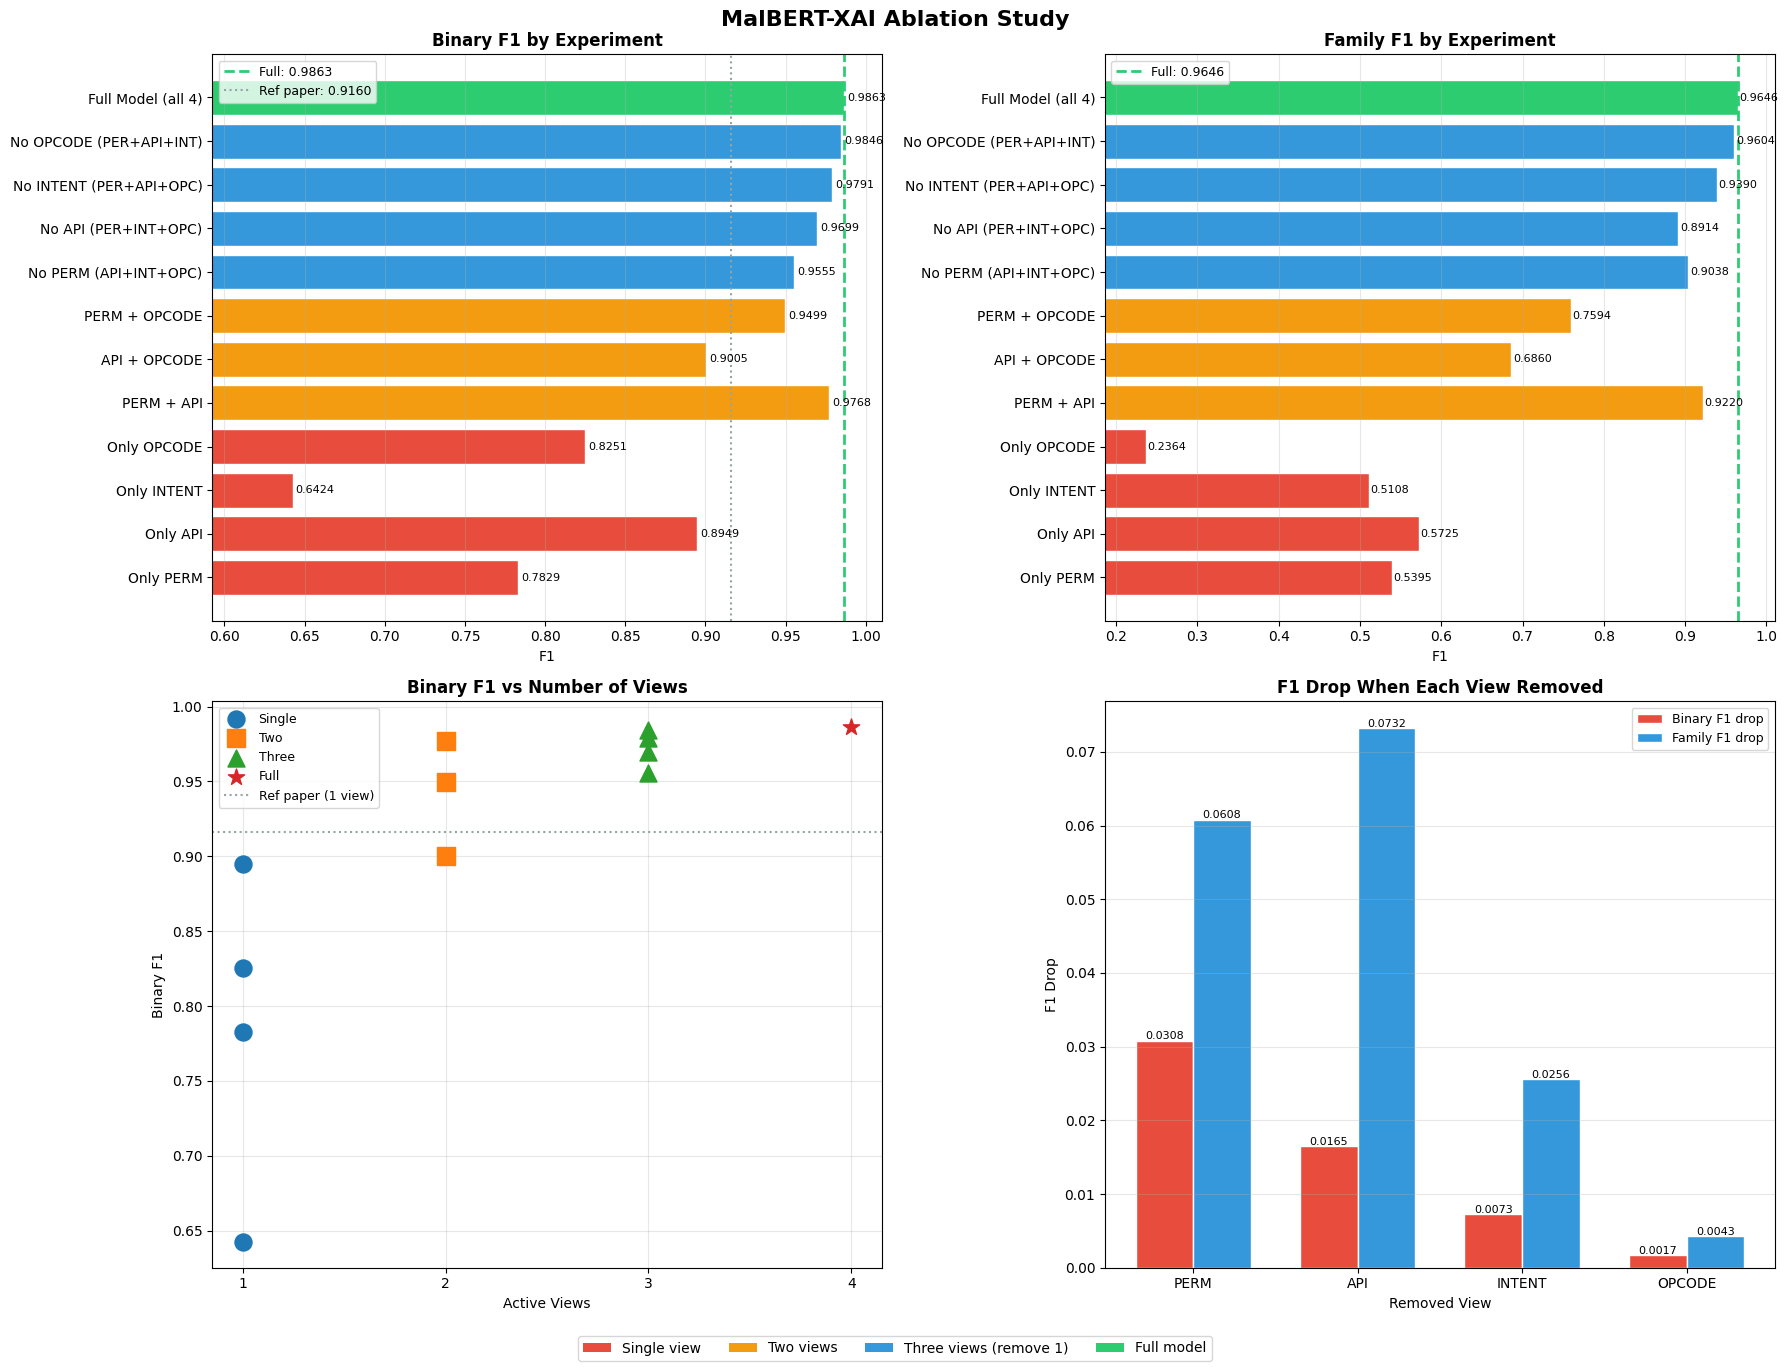

Saved: ablation_results.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("MalBERT-XAI Ablation Study", fontweight="bold", fontsize=16)

names      = list(ablation_results.keys())
bin_f1s    = [ablation_results[n]["binary_f1"] for n in names]
fam_f1s    = [ablation_results[n]["family_f1"] for n in names]
nv_list    = [ablation_results[n]["num_views"] for n in names]

def gcol(n):
    if "Only" in n: return "#E74C3C"
    if "+" in n and "No" not in n and n.count("+")==1: return "#F39C12"
    if "No" in n: return "#3498DB"
    return "#2ECC71"
colors = [gcol(n) for n in names]

# Plot 1: Binary F1
bars=axes[0,0].barh(names,bin_f1s,color=colors,edgecolor="white")
axes[0,0].axvline(full_bin_f1,color="#2ECC71",linewidth=2,linestyle="--",label=f"Full: {full_bin_f1:.4f}")
axes[0,0].axvline(0.916,color="#95A5A6",linewidth=1.5,linestyle=":",label="Ref paper: 0.9160")
axes[0,0].set_title("Binary F1 by Experiment",fontweight="bold"); axes[0,0].set_xlabel("F1")
axes[0,0].set_xlim(min(bin_f1s)-0.05,1.01)
for bar,v in zip(bars,bin_f1s): axes[0,0].text(bar.get_width()+0.002,bar.get_y()+bar.get_height()/2,f"{v:.4f}",va="center",fontsize=8)
axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3,axis="x")

# Plot 2: Family F1
bars=axes[0,1].barh(names,fam_f1s,color=colors,edgecolor="white")
axes[0,1].axvline(full_fam_f1,color="#2ECC71",linewidth=2,linestyle="--",label=f"Full: {full_fam_f1:.4f}")
axes[0,1].set_title("Family F1 by Experiment",fontweight="bold"); axes[0,1].set_xlabel("F1")
axes[0,1].set_xlim(min(fam_f1s)-0.05,1.01)
for bar,v in zip(bars,fam_f1s): axes[0,1].text(bar.get_width()+0.002,bar.get_y()+bar.get_height()/2,f"{v:.4f}",va="center",fontsize=8)
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3,axis="x")

# Plot 3: F1 vs Num Views
for nv,mk,lbl in [(1,"o","Single"),(2,"s","Two"),(3,"^","Three"),(4,"*","Full")]:
    ys=[ablation_results[n]["binary_f1"] for n in names if ablation_results[n]["num_views"]==nv]
    axes[1,0].scatter([nv]*len(ys),ys,marker=mk,s=150,label=lbl,zorder=5)
axes[1,0].axhline(0.916,color="#95A5A6",linewidth=1.5,linestyle=":",label="Ref paper (1 view)")
axes[1,0].set_title("Binary F1 vs Number of Views",fontweight="bold")
axes[1,0].set_xlabel("Active Views"); axes[1,0].set_ylabel("Binary F1")
axes[1,0].set_xticks([1,2,3,4]); axes[1,0].legend(fontsize=9); axes[1,0].grid(alpha=0.3)

# Plot 4: Drop when removed
vnames=["PERM","API","INTENT","OPCODE"]
no_map={"PERM":"No PERM (API+INT+OPC)","API":"No API (PER+INT+OPC)","INTENT":"No INTENT (PER+API+OPC)","OPCODE":"No OPCODE (PER+API+INT)"}
db=[full_bin_f1-ablation_results[no_map[v]]["binary_f1"] for v in vnames]
df_=[full_fam_f1-ablation_results[no_map[v]]["family_f1"] for v in vnames]
x=np.arange(4); w=0.35
axes[1,1].bar(x-w/2,db,w,label="Binary F1 drop",color="#E74C3C",edgecolor="white")
axes[1,1].bar(x+w/2,df_,w,label="Family F1 drop",color="#3498DB",edgecolor="white")
axes[1,1].set_title("F1 Drop When Each View Removed",fontweight="bold")
axes[1,1].set_xlabel("Removed View"); axes[1,1].set_ylabel("F1 Drop")
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(vnames)
axes[1,1].legend(fontsize=9); axes[1,1].grid(alpha=0.3,axis="y")
for i,(d1,d2) in enumerate(zip(db,df_)):
    axes[1,1].text(i-w/2,d1+0.0002,f"{d1:.4f}",ha="center",fontsize=8)
    axes[1,1].text(i+w/2,d2+0.0002,f"{d2:.4f}",ha="center",fontsize=8)

leg=[mpatches.Patch(facecolor=c,label=l) for c,l in [("#E74C3C","Single view"),("#F39C12","Two views"),("#3498DB","Three views (remove 1)"),("#2ECC71","Full model")]]
fig.legend(handles=leg,loc="lower center",ncol=4,fontsize=10,bbox_to_anchor=(0.5,0.01))
plt.tight_layout(rect=[0,0.04,1,1])
plt.savefig(os.path.join(ABLATION_DIR,"ablation_results.png"),dpi=150,bbox_inches="tight")
plt.show()
print("Saved: ablation_results.png")

## Cell 7: Save Results

In [8]:
save_data = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "test_size": len(test_df),
    "device": str(device),
    "baseline": {"binary_f1": full_bin_f1, "family_f1": full_fam_f1,
                 "binary_acc": full_bin_acc, "family_acc": full_fam_acc},
    "experiments": {
        name: {"active_views": r["active_views"], "num_views": r["num_views"],
               "binary_f1": round(r["binary_f1"],6), "family_f1": round(r["family_f1"],6),
               "binary_acc": round(r["binary_acc"],6), "family_acc": round(r["family_acc"],6),
               "binary_f1_drop": round(full_bin_f1-r["binary_f1"],6),
               "family_f1_drop": round(full_fam_f1-r["family_f1"],6)}
        for name,r in ablation_results.items()
    },
    "key_findings": {
        "best_single_view": best_single,
        "best_single_f1": round(ablation_results[best_single]["binary_f1"],6),
        "most_important_view": most_imp,
        "least_important_view": least_imp,
        "multiview_gain_over_best_single": round(full_bin_f1-ablation_results[best_single]["binary_f1"],6),
        "gain_over_ref_paper": round(full_bin_f1-0.916,6),
    }
}
sp = os.path.join(ABLATION_DIR, "ablation_results.json")
with open(sp,"w") as f: json.dump(save_data,f,indent=2)
print(f"JSON saved:  {sp}")
print(f"Plot saved:  {os.path.join(ABLATION_DIR,'ablation_results.png')}")
print(f"Folder:      {ABLATION_DIR}")
print("\nABLATION STUDY COMPLETE")
bsf = ablation_results[best_single]['binary_f1']
gain = full_bin_f1 - bsf
ref_gain = full_bin_f1 - 0.916
print(f"  Best single view:  {best_single} (F1={bsf:.4f})")
print(f"  Multi-view gain:   +{gain:.4f} over best single")
print(f"  Gain vs ref paper: +{ref_gain:.4f}")

JSON saved:  /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/ablation_study/ablation_results.json
Plot saved:  /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/ablation_study/ablation_results.png
Folder:      /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/ablation_study

ABLATION STUDY COMPLETE
  Best single view:  Only API (F1=0.8949)
  Multi-view gain:   +0.0914 over best single
  Gain vs ref paper: +0.0703
